In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from src.train import load_featured_data, prepare_data, FEATURE_COLS

sns.set_theme(style='whitegrid', font_scale=1.1)
shap.initjs()

print("All imports OK!")

All imports OK!


In [2]:
# load data
df = load_featured_data()
X_train, X_test, y_train, y_test, train_df, test_df = prepare_data(df)

# load saved XGBoost model
xgb_model = joblib.load('../models/xgboost.pkl')

print("Model and data loaded!")
print(f"Test set shape: {X_test.shape}")

  Loaded f1_features.csv  →  26,759 rows  60 cols

  Train: 9,904 rows  (1994–2019)
  Test:  2,139 rows  (2020–2024)

  Train podium rate: 14.2%
  Test  podium rate: 15.0%
Model and data loaded!
Test set shape: (2139, 22)


In [3]:
print("Computing SHAP values (this takes ~30 seconds)...")

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("Done!")

Computing SHAP values (this takes ~30 seconds)...
SHAP values shape: (2139, 22)
Done!


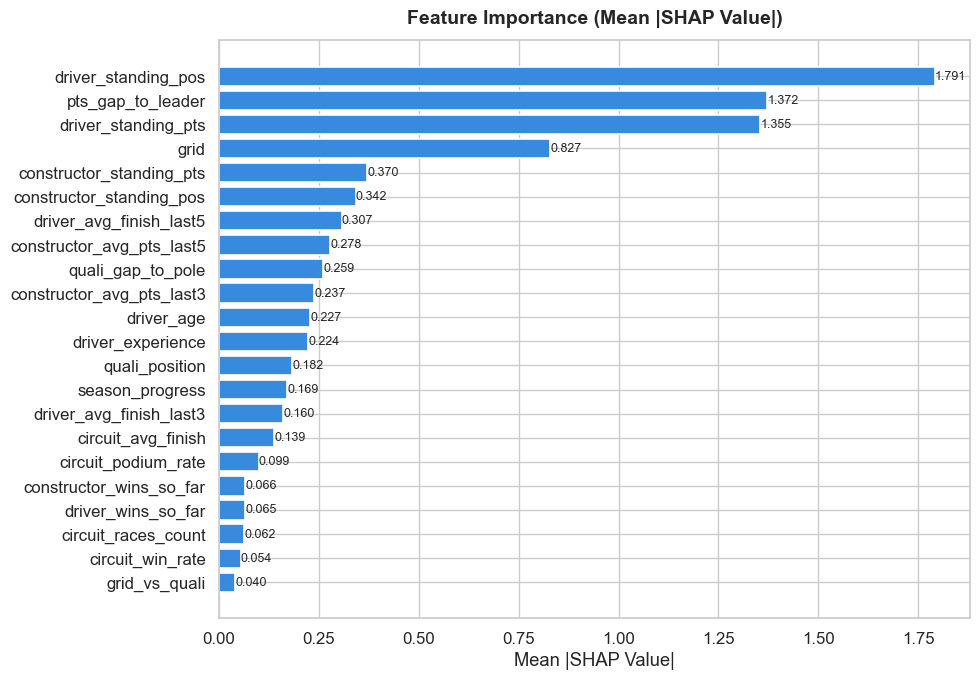


Top 5 most important features:
  driver_standing_pos                 1.7911
  pts_gap_to_leader                   1.3721
  driver_standing_pts                 1.3547
  grid                                0.8274
  constructor_standing_pts            0.3701


In [4]:
# mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    shap_importance['feature'],
    shap_importance['importance'],
    color='#378ADD', edgecolor='white', linewidth=1.2
)
ax.invert_yaxis()
ax.set_title('Feature Importance (Mean |SHAP Value|)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mean |SHAP Value|')
for bar, val in zip(bars, shap_importance['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for i, row in shap_importance.head(5).iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f}")

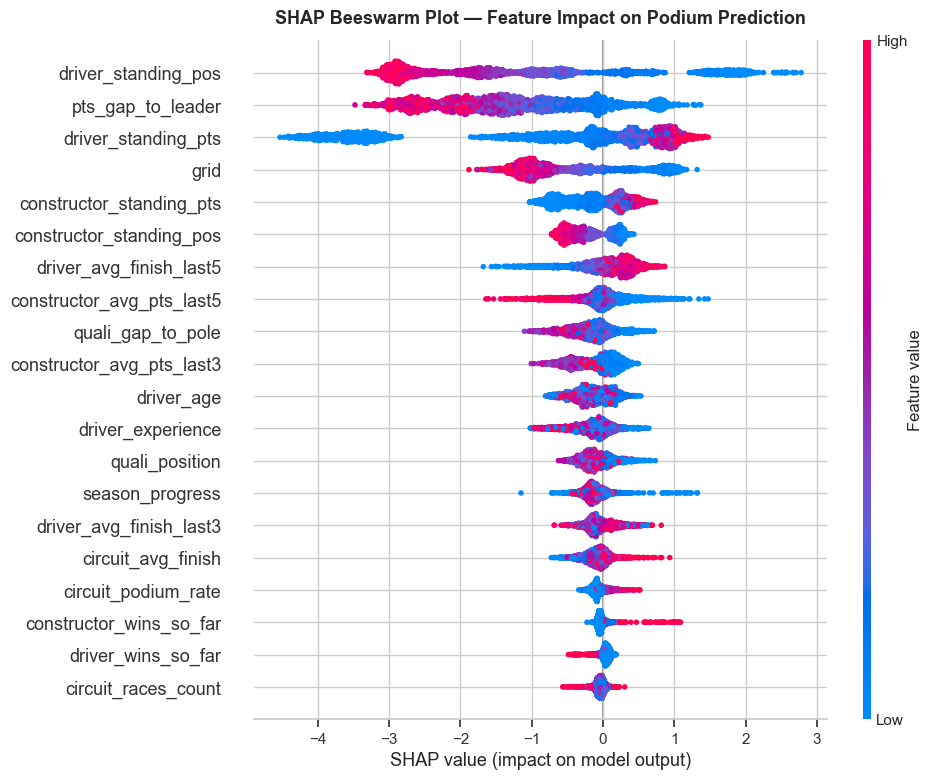

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None
)
plt.title('SHAP Beeswarm Plot — Feature Impact on Podium Prediction',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Explaining prediction for:
  Driver:      hamilton
  Race:        Styrian Grand Prix
  Year:        2020
  Grid:        1
  Actual:      Podium
  Predicted:   Podium
  Probability: 94.2%



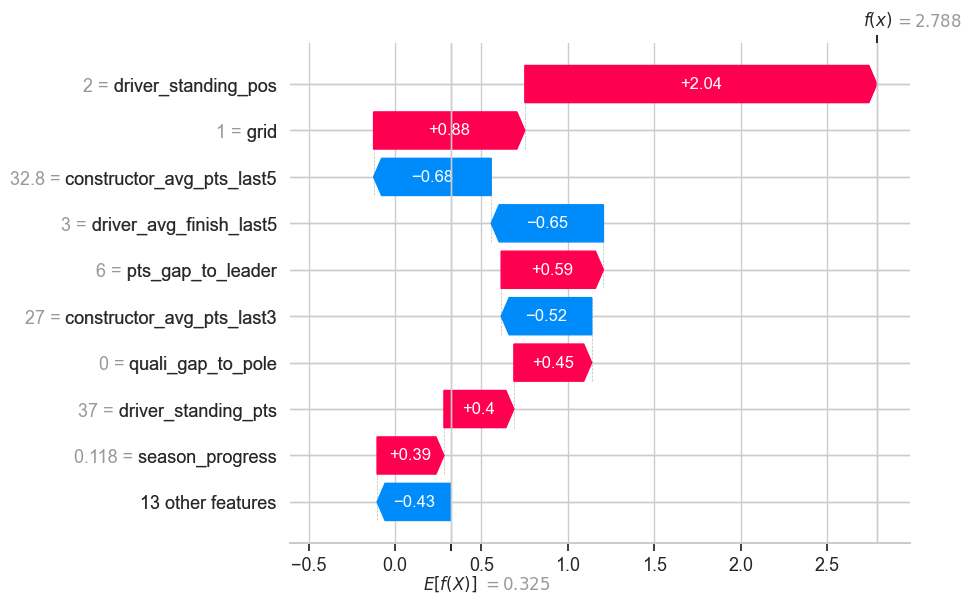

In [7]:
# pick a podium finisher from the test set to explain
podium_idx = np.where(y_test.values == 1)[0][0]

print(f"Explaining prediction for:")
print(f"  Driver:      {test_df.iloc[podium_idx]['driverRef']}")
print(f"  Race:        {test_df.iloc[podium_idx]['name']}")
print(f"  Year:        {test_df.iloc[podium_idx]['year']}")
print(f"  Grid:        {test_df.iloc[podium_idx]['grid']}")
print(f"  Actual:      {'Podium' if y_test.values[podium_idx] == 1 else 'No Podium'}")
print(f"  Predicted:   {'Podium' if xgb_model.predict(X_test.iloc[[podium_idx]])[0] == 1 else 'No Podium'}")
print(f"  Probability: {xgb_model.predict_proba(X_test.iloc[[podium_idx]])[0][1]:.1%}\n")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[podium_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[podium_idx],
        feature_names=FEATURE_COLS
    )
)

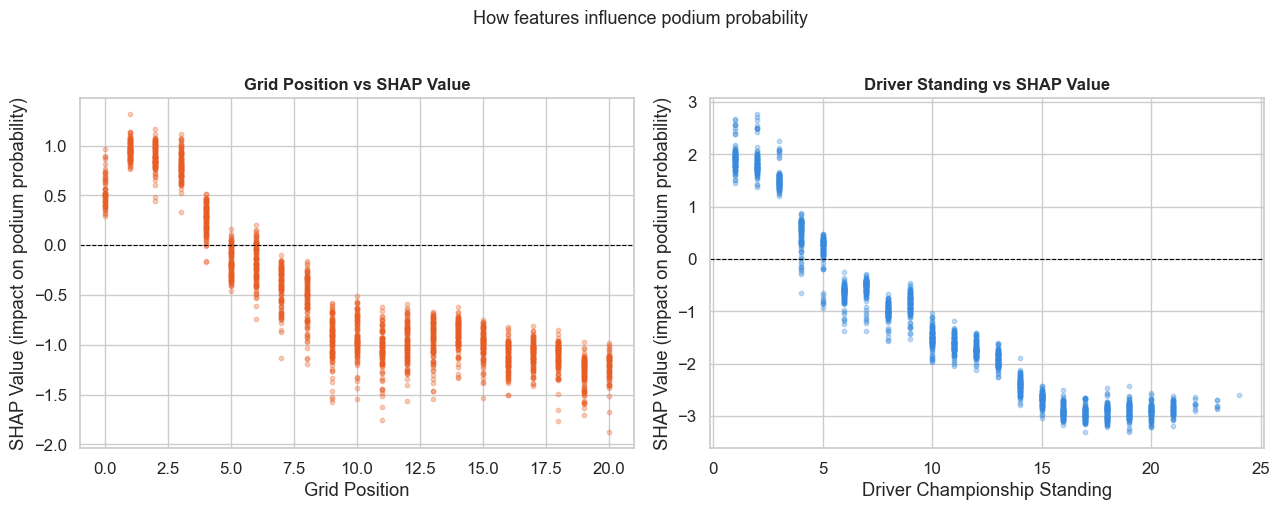

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# grid position vs SHAP value
axes[0].scatter(
    X_test['grid'],
    shap_values[:, FEATURE_COLS.index('grid')],
    alpha=0.3, color='#E85D24', s=10
)
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Grid Position vs SHAP Value', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Grid Position')
axes[0].set_ylabel('SHAP Value (impact on podium probability)')

# driver standing pos vs SHAP value
axes[1].scatter(
    X_test['driver_standing_pos'],
    shap_values[:, FEATURE_COLS.index('driver_standing_pos')],
    alpha=0.3, color='#378ADD', s=10
)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Driver Standing vs SHAP Value', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Driver Championship Standing')
axes[1].set_ylabel('SHAP Value (impact on podium probability)')

plt.suptitle('How features influence podium probability', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()